# SVM Classification of Hyperspectral Imagery with Tucker Decomposition

---

This notebook evaluates the performance of an **SVM classifier** on hyperspectral satellite imagery, before and after **Tucker Decomposition**.

Tucker Decomposition is used as a preprocessing step to remove noise and redundancy by reducing the dimensionality of the data tensor, producing a compact lower-rank approximation.

**Dataset:** Indian Pines — AVIRIS sensor

| Property | Value |
|---|---|
| Spatial resolution | 20 m |
| Spectral resolution | 10 nm |
| Spectral bands | 200 |
| Image size | 145 × 145 px |
| Classes | 16 land-cover types + background |

**Pipeline:**
1. Baseline SVM on raw spectral features (grid search + 5-fold CV)
2. Tucker Decomposition with AIC-based rank selection
3. SVM on Tucker-compressed features

---


In [26]:
import tensorly as tl
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data

---

The background class (label = 0) is masked out before modelling, as it does not correspond to a meaningful land-cover type.


In [14]:
pines = pd.read_csv('IndianPines.csv', header=0)

# Full data (for visualization)
X_full = pines.iloc[:, :-1].to_numpy()
Y_full = pines.iloc[:, -1].to_numpy()

# Filtered data (for modeling)
mask = Y_full != 0
X = X_full[mask]
Y = Y_full[mask]


### RGB approximation and class map

Bands 30, 20, and 10 are mapped to R, G, and B channels to produce a natural-colour approximation of the scene.


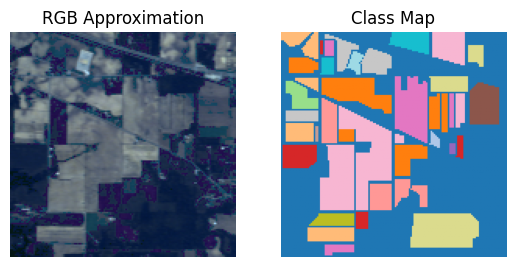

In [15]:
# Choosing bands to simulate real picture
R = X_full[:, 30]
G = X_full[:, 20]
B = X_full[:, 10]

# matrices to plot
rgb = np.stack([R, G, B], axis=1)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
rgb_img = rgb.reshape(145, 145, 3)
class_img = Y_full.reshape(145, 145)

fig, axes = plt.subplots(1, 2)
# RGB image
axes[0].imshow(rgb_img)
axes[0].set_title("RGB Approximation")
axes[0].axis('off')
# class map image
axes[1].imshow(class_img, cmap='tab20')  # enough colors for all 16 classes
axes[1].set_title("Class Map")
axes[1].axis('off')

plt.show()


---

## 2. Baseline SVM on Raw Spectral Features

---

Before applying Tucker Decomposition, we establish a baseline by training an SVM directly on the 200-band spectral features.

Hyperparameters are selected via **5-fold cross-validated grid search** over:

| Hyperparameter | Values searched |
|---|---|
| $C$ | 0.1, 1, 10, 50 |
| $\gamma$ | scale, 0.01, 0.001, 0.0001 |
| Kernel | RBF, Linear |


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(class_weight='balanced'))
])

# Parameter grid
param_grid = {
    'svc__C': [0.1, 1, 10, 50],
    'svc__gamma': ['scale', 0.01, 0.001, 0.0001],
    'svc__kernel': ['rbf', 'linear']
}

# Grid search
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

# Fit
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Params: {'svc__C': 50, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best CV Score: 0.9056320615806277


### Test accuracy and confusion matrix


In [17]:
# Get best model
best_model = grid.best_estimator_

# Predict on test set
yhat = best_model.predict(X_test)

# Accuracy
accuracy = np.mean(yhat == y_test)
print("Test Accuracy:", str(round(accuracy * 100, 2)) + "%")
print("Chosen Parameters:", best_model[1])


Test Accuracy: 90.93%
Chosen Parameters: SVC(C=50, class_weight='balanced', gamma=0.01)


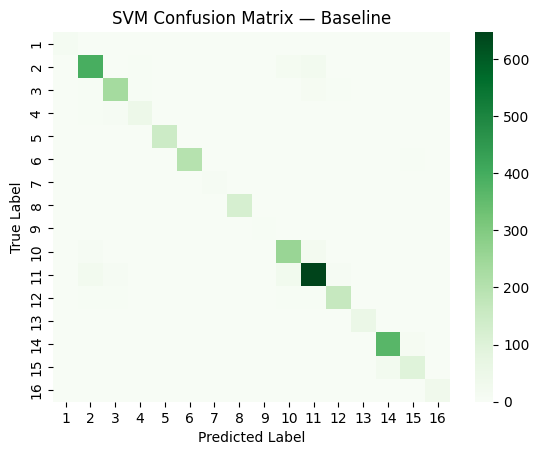

In [18]:
labels = np.unique(np.unique(Y))
cm = confusion_matrix(y_test, yhat, labels=labels)
sns.heatmap(cm, cmap='Greens', xticklabels=labels, yticklabels=labels)

# Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Baseline')
plt.show()


---

## 3. Tucker Decomposition

---

The image is reshaped into a **3rd-order tensor** $\mathcal{X} \in \mathbb{R}^{145 \times 145 \times 200}$ and decomposed using Tucker Decomposition:

$$\mathcal{X} \approx \mathcal{G} \times_1 A \times_2 B \times_3 C$$

where $\mathcal{G}$ is the core tensor and $A, B, C$ are the factor matrices.

We use a **symmetric rank** $R = R_1 = R_2 = R_3$ and sweep $R \in \{5, 10, \ldots, 135\}$, selecting the optimal rank via **AIC**:

$$\text{AIC} = n \log\left(\frac{\text{RSS}}{n}\right) + 2k$$

where $k$ is the total number of parameters in the decomposition and $n$ is the number of elements in $\mathcal{X}$.


### 3.1 Reshape data to 3rd-order tensor


In [19]:
classes = pines.iloc[:, -1]
pines = pines.iloc[:, :-1]

pines = np.asarray(pines).reshape(145, 145, 200)
pines.shape


(145, 145, 200)

### 3.2 Sweep rank $R$ and compute AIC


In [24]:
AIC_list = []

Rs = range(5, 140, 5)  # Using the same rank for each dimension

for R in Rs:
    tucker = tl.decomposition.tucker(pines, [R,R,R])

    A = tucker[1][0]
    B = tucker[1][1]
    C = tucker[1][2]

    A_size = A.shape[0]*A.shape[1]
    B_size = B.shape[0]*B.shape[1]
    C_size = C.shape[0]*C.shape[1]
    core_size = np.prod(tucker[0].size)

    k = A_size + B_size + C_size + core_size

    pines_estimated = tl.tucker_to_tensor(tucker)  # Reconstruct

    residuals = pines - pines_estimated
    RSS = np.sum(residuals**2)
    n = pines.size
    AIC = n * np.log(RSS / n) + 2 * k

    AIC_list.append(AIC)


### 3.3 Select optimal rank via AIC


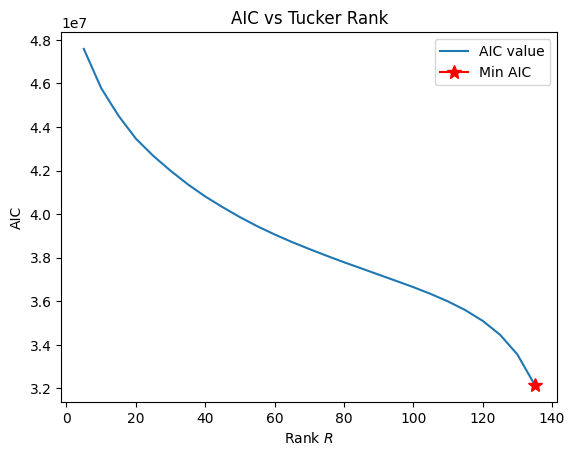

In [25]:
Rmin = Rs[np.argmin(AIC_list)]
AIC_min = min(AIC_list)

plt.plot(Rs, AIC_list, label='AIC value')
plt.plot(Rmin, AIC_min, marker='*', markersize=10, color='red', label='Min AIC')
plt.xlabel("Rank $R$")
plt.ylabel("AIC")
plt.title("AIC vs Tucker Rank")
plt.legend()
plt.show()


---

## 4. SVM on Tucker-Compressed Features

---

The Tucker-reconstructed tensor is flattened back to pixel × band format, background pixels are removed, and the result is z-score normalised before fitting the SVM.


In [22]:
pines_estimated = np.asarray(pines_estimated).reshape(21025, 200)  # Taking shortcut by using last AIC value as best
pines_estimated = pines_estimated[classes[classes != 0]]
pines_estimated = (pines_estimated - pines_estimated.mean(axis=0)) / pines_estimated.std(axis=0)

classes = classes[classes != 0]

X_train, X_test, y_train, y_test = train_test_split(pines_estimated, classes, test_size=0.9)

clf = SVC(kernel='rbf')
clf = clf.fit(X_train, y_train)

yhat = clf.predict(X_test)


### Test accuracy and confusion matrix


SVM Accuracy: 99.51%


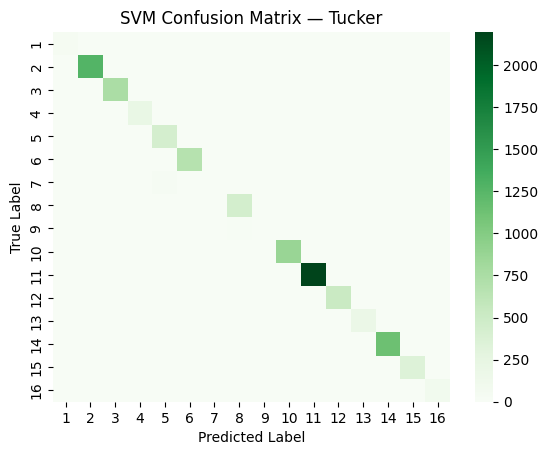

In [23]:
accuracy = np.sum(yhat == y_test) / len(y_test)
print("SVM Accuracy:", str(round(accuracy * 100, 2)) + "%")

labels = np.unique(np.unique(classes))
cm = confusion_matrix(y_test, yhat, labels=labels)
sns.heatmap(cm, cmap='Greens', xticklabels=labels, yticklabels=labels)

# Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Tucker')
plt.show()
